In [1]:
import spacy
import pandas as pd

# 1. Carichiamo il modello di Intelligenza Artificiale per l'italiano
print("Caricamento del modello NLP...")
nlp = spacy.load("it_core_news_md")
print("Modello caricato con successo!\n")

# 2. Facciamo un test con una frase finta ma realistica
testo_prova = "Il Garante della Privacy ha sanzionato il Comune di Milano e l'azienda Clearview AI per l'utilizzo del riconoscimento facciale."

# Passiamo il testo al modello
documento = nlp(testo_prova)

# 3. Estraiamo le "Entità Nominate" (Named Entities)
print("--- ANALISI DEL TESTO ---")
print(f"Testo originale: {testo_prova}\n")

print("Entità trovate dall'IA:")
for entita in documento.ents:
    # entita.text è la parola, entita.label_ è la categoria (es. ORG, LOC, PER)
    print(f"- {entita.text} ---> [Categoria: {entita.label_}]")

Caricamento del modello NLP...
Modello caricato con successo!

--- ANALISI DEL TESTO ---
Testo originale: Il Garante della Privacy ha sanzionato il Comune di Milano e l'azienda Clearview AI per l'utilizzo del riconoscimento facciale.

Entità trovate dall'IA:
- Garante della Privacy ---> [Categoria: MISC]
- Comune di Milano ---> [Categoria: LOC]
- Clearview ---> [Categoria: PER]


In [2]:
import pandas as pd
from collections import Counter

# 1. Carichiamo il CSV grezzo delle ONG (assumendo che il notebook sia nella cartella 'notebooks')
percorso_ong = '../data/raw/ong_sample.csv'
df_ong = pd.read_csv(percorso_ong)

print(f"Caricati {len(df_ong)} comunicati delle organizzazioni civiche.\n")

# 2. Creiamo la funzione "Filtro NLP"
def estrai_attori_chiave(testo):
    """Analizza il testo ed estrae solo Organizzazioni (ORG) e Luoghi/Istituzioni (LOC)"""
    # Mettiamo una protezione nel caso in cui il testo sia vuoto
    if not isinstance(testo, str):
        return []
        
    doc = nlp(testo)
    attori = []
    for ent in doc.ents:
        if ent.label_ in ['ORG', 'LOC']:
            # Puliamo leggermente il testo per evitare duplicati sporchi
            attori.append(ent.text.strip())
    return attori

# 3. Il momento della verità: applichiamo l'IA a tutta la colonna 'Titolo'
print("Elaborazione NLP in corso... (potrebbe volerci qualche secondo sui grandi dataset)")
df_ong['Attori_Coinvolti'] = df_ong['Titolo'].apply(estrai_attori_chiave)

# 4. Vediamo i risultati riga per riga
print("\n--- RISULTATI ESTRAZIONE ENTITÀ ---")
# Usiamo display() che su Jupyter/VS Code crea una tabella bella e formattata
display(df_ong[['ONG', 'Titolo', 'Attori_Coinvolti']].head(10))

# 5. La Classifica: Chi è l'ente/azienda più "bersagliato"?
# Uniamo tutte le liste di attori in un'unica grande lista
tutti_gli_attori = [attore for lista in df_ong['Attori_Coinvolti'] for attore in lista]
classifica = Counter(tutti_gli_attori)

print("\n--- I BERSAGLI/ATTORI PIÙ CITATI NELLE CAMPAGNE ONG ---")
for attore, conteggio in classifica.most_common(10):
    print(f"- {attore} ({conteggio} citazioni)")

Caricati 51 comunicati delle organizzazioni civiche.

Elaborazione NLP in corso... (potrebbe volerci qualche secondo sui grandi dataset)

--- RISULTATI ESTRAZIONE ENTITÀ ---


,ONG,Titolo,Attori_Coinvolti
0,Hermes Center,Mozilla Festival 2025: la retorica sull’IA e l...,"[IA, Sud]"
1,The Good Lobby Italia,"Epstein Files: scandali, potere politico e por...",[]
2,The Good Lobby Italia,SLAPP: Italia ancora prima in Europa. Leggi il...,"[SLAPP, Italia, Europa]"
3,The Good Lobby Italia,Referendum 2026: votare fuorisede come rappres...,[]
4,The Good Lobby Italia,L’agenda europea “catturata” dalle potenti lob...,[]
5,The Good Lobby Italia,Come funziona davvero il lobbying nelle stanze...,[]
6,The Good Lobby Italia,11 multinazionali contro la direttiva UE sulla...,[UE]
7,The Good Lobby Italia,Doha 2025: la svolta dell’ONU sulla trasparenz...,[ONU]
8,The Good Lobby Italia,Anatomia della legge di bilancio: il lobbying ...,[]
9,The Good Lobby Italia,La Consulta: “Il legislatore regoli il lobbying”,[]



--- I BERSAGLI/ATTORI PIÙ CITATI NELLE CAMPAGNE ONG ---
- IA (1 citazioni)
- Sud (1 citazioni)
- SLAPP (1 citazioni)
- Italia (1 citazioni)
- Europa (1 citazioni)
- UE (1 citazioni)
- ONU (1 citazioni)
- Europe’s digital sovereignty starts with open source (1 citazioni)
- US pressure on the Digital Services Act (1 citazioni)
- European Commission’s plans will lead to worse regulations (1 citazioni)


Costruzione della mappa di advocacy in corso...


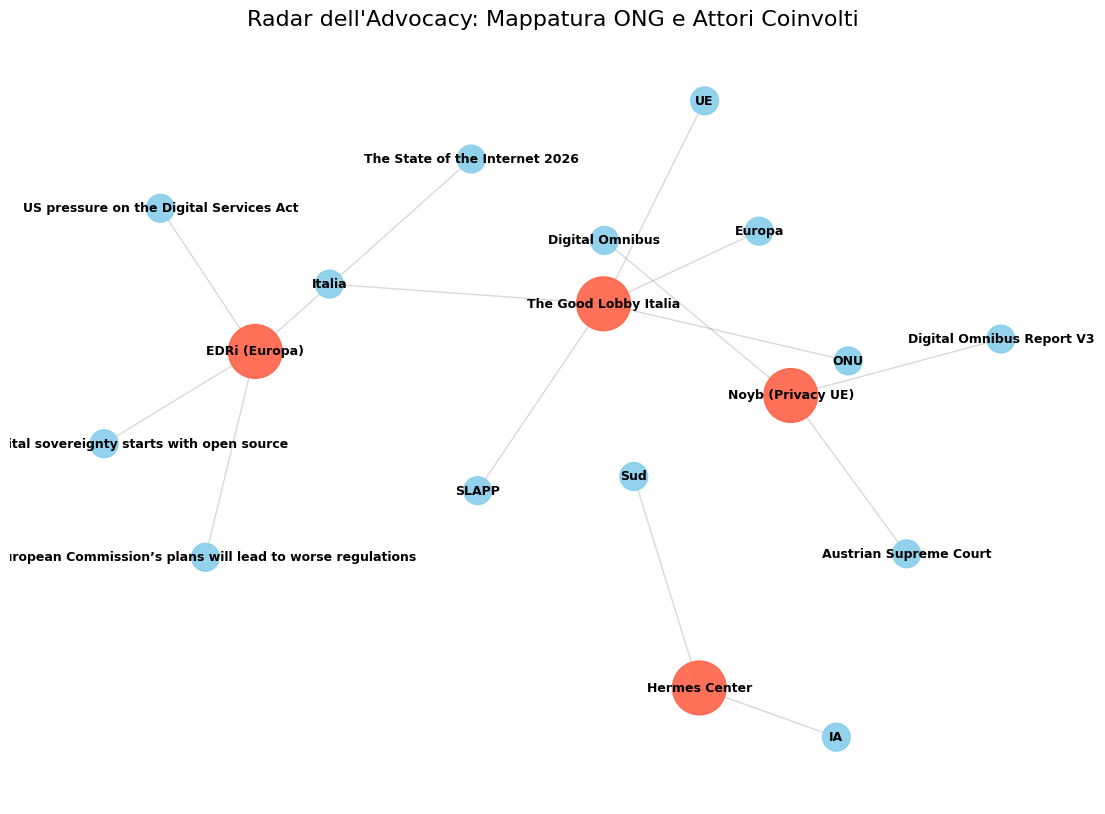

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Creiamo la tela vuota per il nostro Grafo
G = nx.Graph()

print("Costruzione della mappa di advocacy in corso...")

# 2. Creiamo le connessioni (Nodi e Archi)
# iterrows() ci permette di leggere il dataframe riga per riga
for indice, riga in df_ong.iterrows():
    ong = riga['ONG']
    attori = riga['Attori_Coinvolti']
    
    # Se l'IA non ha trovato nessun attore in quel titolo, saltiamo
    if not attori:
        continue
        
    # Aggiungiamo l'ONG come nodo centrale
    G.add_node(ong, tipo='ONG')
    
    # Per ogni attore trovato, creiamo un nodo e lo colleghiamo all'ONG
    for attore in attori:
        # Aggiungiamo l'attore alla mappa
        G.add_node(attore, tipo='Bersaglio')
        # Tiriamo una linea tra l'ONG e l'attore!
        G.add_edge(ong, attore)

# 3. Impostiamo la grafica (Colori e Dimensioni)
colori = []
dimensioni = []
for nodo, dati in G.nodes(data=True):
    if dati.get('tipo') == 'ONG':
        colori.append('tomato') # Le ONG sono rosse
        dimensioni.append(1500) # e più grandi
    else:
        colori.append('skyblue') # I bersagli sono azzurri
        # Se un bersaglio è molto citato (ha molti collegamenti), lo facciamo più grande
        grado_connessione = G.degree(nodo)
        dimensioni.append(300 + (grado_connessione * 100))

# 4. Disegniamo la mappa
plt.figure(figsize=(14, 10))
# Calcoliamo la posizione dei punti (k indica quanto stanno "lontani" tra loro)
posizioni = nx.spring_layout(G, k=0.8, iterations=50)

# Disegniamo le linee
nx.draw_networkx_edges(G, posizioni, alpha=0.3, edge_color='gray')
# Disegniamo i punti
nx.draw_networkx_nodes(G, posizioni, node_color=colori, node_size=dimensioni, alpha=0.9)
# Scriviamo i nomi
nx.draw_networkx_labels(G, posizioni, font_size=9, font_weight='bold')

plt.title("Radar dell'Advocacy: Mappatura ONG e Attori Coinvolti", fontsize=16)
plt.axis('off') # Togliamo gli assi X e Y per farlo sembrare una vera mappa
plt.show()

Caricati 10 provvedimenti completi del Garante.



,Titolo,Ambito_Geografico,Entita_Coinvolte
0,Dal Garante ok alle Linee guida Agid sull’acce...,Europa,"[Autorità - Sanità, Maggiori, Ateneo, Pescara,..."
1,COMUNICATO STAMPA - Garante privacy ad Amazon:...,Italia,"[February 2026 Provvedimento, Italy, Amazon, G..."
2,Garante privacy al comune di Pescara: no alle ...,Europa,"[Autorità - Sanità, Maggiori, Ateneo, Pescara,..."
3,"COMUNICATO STAMPA - Sanità: Garante privacy, s...",Europa,[Regolamento Ue]
4,Lavoro: l’accesso alla email del lavoratore li...,Europa,"[Comitato Europeo, Https://Www.Garanteprivacy...."


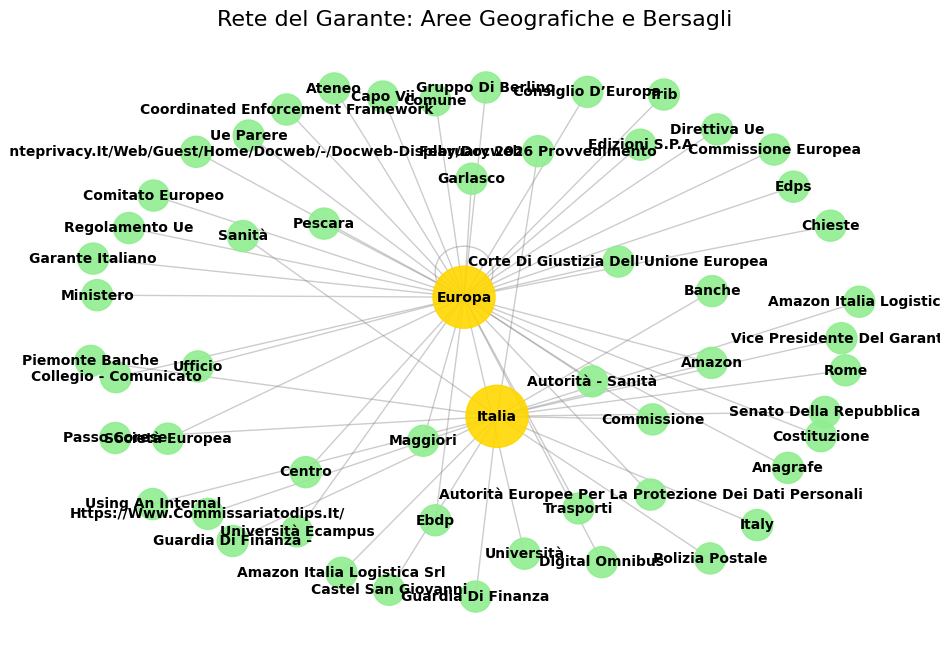

In [3]:
import pandas as pd
import ast
import networkx as nx
import matplotlib.pyplot as plt

# 1. Carichiamo i dati "puliti" del Garante che il tuo script .py ha appena creato
percorso_garante = '../data/processed/gpdp_analyzed.csv'
df_garante = pd.read_csv(percorso_garante)

# Convertiamo le stringhe in vere liste
df_garante['Entita_Coinvolte'] = df_garante['Entita_Coinvolte'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

print(f"Caricati {len(df_garante)} provvedimenti completi del Garante.\n")
display(df_garante[['Titolo', 'Ambito_Geografico', 'Entita_Coinvolte']].head(5))

# 2. Creiamo il Grafo di Rete del Garante!
G_garante = nx.Graph()

for indice, riga in df_garante.iterrows():
    ambito = riga['Ambito_Geografico']
    entita_lista = riga['Entita_Coinvolte']
    
    if not entita_lista:
        continue
        
    # Usiamo l'Ambito Geografico come nodo centrale (es. "Europa" o "USA")
    G_garante.add_node(ambito, tipo='Geografia')
    
    for entita in entita_lista:
        G_garante.add_node(entita, tipo='Bersaglio')
        G_garante.add_edge(ambito, entita)

# 3. Disegniamo la mappa
colori = []
dimensioni = []
for nodo, dati in G_garante.nodes(data=True):
    if dati.get('tipo') == 'Geografia':
        colori.append('gold') 
        dimensioni.append(2000)
    else:
        colori.append('lightgreen') 
        dimensioni.append(500)

plt.figure(figsize=(12, 8))
posizioni = nx.spring_layout(G_garante, k=0.9, iterations=50)
nx.draw_networkx_edges(G_garante, posizioni, alpha=0.4, edge_color='gray')
nx.draw_networkx_nodes(G_garante, posizioni, node_color=colori, node_size=dimensioni, alpha=0.9)
nx.draw_networkx_labels(G_garante, posizioni, font_size=10, font_weight='bold')

plt.title("Rete del Garante: Aree Geografiche e Bersagli", fontsize=16)
plt.axis('off')
plt.show()

In [4]:
import pandas as pd
import ast
import plotly.graph_objects as go
from collections import Counter

# 1. Caricamento Dati
percorso_garante = '../data/processed/gpdp_analyzed.csv'
df_garante = pd.read_csv(percorso_garante)
df_garante['Entita_Coinvolte'] = df_garante['Entita_Coinvolte'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# 2. Prepariamo i flussi
# 2. Prepariamo i flussi
collegamenti = []
for _, riga in df_garante.iterrows():
    geo = riga['Ambito_Geografico']
    for entita in riga['Entita_Coinvolte']:
        # --- LO SCUDO ANTI-CORTOCIRCUITO ---
        # Colleghiamo solo se il nome dell'entità NON è uguale all'area geografica
        if geo.lower() not in entita.lower() and entita.lower() not in geo.lower():
            collegamenti.append((geo, entita))

conteggio_flussi = Counter(collegamenti)

nodi_geo = list(set([c[0] for c in conteggio_flussi.keys()]))
nodi_entita = list(set([c[1] for c in conteggio_flussi.keys()]))
tutti_i_nodi = nodi_geo + nodi_entita
mappa_id = {nodo: i for i, nodo in enumerate(tutti_i_nodi)}

sorgenti = [mappa_id[c[0]] for c in conteggio_flussi.keys()]
destinazioni = [mappa_id[c[1]] for c in conteggio_flussi.keys()]
spessori = list(conteggio_flussi.values())

# --- RESTYLING GRAFICO ---

# A. Colori allegri: Blu per la geografia, Arancione per le aziende
colori_nodi = []
for nodo in tutti_i_nodi:
    if nodo in nodi_geo:
        colori_nodi.append('#1E88E5') # Blu vivace
    else:
        colori_nodi.append('#FF9800') # Arancione allegro

# B. Nomi differenziati (HTML per ingrandire solo le aree geografiche)
etichette_formattate = []
for nodo in tutti_i_nodi:
    if nodo in nodi_geo:
        # Usiamo HTML per fare il testo in Grassetto (<b>) e più grande (22px)
        etichette_formattate.append(f"<b><span style='font-size: 22px;'>{nodo}</span></b>")
    else:
        etichette_formattate.append(nodo)

# Linee grigio chiaro semitrasparenti per non appesantire il fondo bianco
colore_linee = "rgba(200, 200, 200, 0.45)"

# 3. Disegniamo il grafico arioso con Etichette Dinamiche
fig = go.Figure(data=[go.Sankey(
    arrangement = "snap", 
    node = dict(
      pad = 40, 
      thickness = 25,
      line = dict(color = "white", width = 1), 
      label = etichette_formattate,
      color = colori_nodi,
      # Testo quando passi sul rettangolo
      hovertemplate = "%{label}<extra></extra>" 
    ),
    link = dict(
      source = sorgenti,
      target = destinazioni,
      value = spessori, # <-- È QUESTO CHE REGOLA LO SPESSORE AUTOMATICO!
      color = colore_linee,
      hovercolor = "rgba(255, 152, 0, 0.4)", # Diventa arancione quando ci passi sopra
      # --- NOVITÀ: IL TESTO SULLE LINEE ---
      customdata = spessori,
      hovertemplate = "<b>Da:</b> %{source.label}<br><b>Verso:</b> %{target.label}<br><b>Volume:</b> %{customdata} Documenti<extra></extra>"
  ))])

# 4. Impostazioni Sfondo e Font
fig.update_layout(
    title_text="Mappa delle Sanzioni: Dalle Giurisdizioni ai Bersagli", 
    font_size=14,
    height=850, 
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Figtree, Arial, sans-serif", color="#333333") 
)

fig.show()